In [1]:
# capstone project -- function 1 (2D), week 4

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay, ConvexHull

from bayes_tools import (
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, fit_gp, get_length_scales, loo_predictions,
    fit_y_scale, to_scaled_units,
    compare_kappa_proposals, print_kappa_comparison,
)
from viz_tools import plot_2d_bo, plot_loo_calibration, plot_kappa_sensitivity


# Function 1

2D. Changed to modelling log10 y instead of y and changed the bounding box padding: the y magnitude  in the observed data is huge and this resolves that to some degree.

## Why `log10|y|`

`|y|` spans more than 100 orders of magnitude.. After `fit_gp`'s internal `normalize_y`, eleven of the twelve observations become the *identical* value `0.301511`. Leave-one-out on `y`: R² **−0.56**, and it puts only **42% of point pairs in the right order** — worse than a coin flip. On `log10|y|`: R² **+0.68** and **86%** of pairs ordered correctly, with neither ARD length-scale pinned.

## The live limitation: UCB on `log10|y|` is sign-blind

`log10|y|` models **magnitude**, so UCB maximises `|y|` — but we want `max y`, and on this function the largest `|y|` on record is **negative** (`−3.6e-3` at (0.650114, 0.681526), 13 orders above anything else). So the surrogate's own peak is a place we do *not* want to go, and UCB cannot tell the difference.

So, kappa is really important. s

| `kappa` | proposal | distance to the negative peak |
|---|---|---|
| 0.5 | `[0.6636, 0.6420]` | **0.042** — effectively resampling it |
| 1.0 | `[0.6638, 0.6140]` | 0.069 |
| 3.0 | `[0.5339, 0.4936]` | 0.221 |
| 8.0 | `[0.4768, 0.4526]` | 0.287 |
| ≥ 10 | `[0.0825, 0.8799]` | 0.601 — **both axes on the box edge** |

`KAPPA = 3.0`: low `kappa` exploits straight into the negative peak, 



In [2]:
X_initial = np.load("initial_data/function_1/initial_inputs.npy")
y_initial = np.load("initial_data/function_1/initial_outputs.npy")
D = X_initial.shape[1]

assert D == 2, f"Expected a 2D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))


## Update this once per week

Include the new X and y values from the previous week

In [3]:
new_X = np.array([
    [0.760601, 0.199726],   # week 2
    [0.885365, 0.523889],   # week 3
])

new_y = np.array([
    -3.77292444076289e-115,
    2.3947473571694736e-54,
])

print("observations collected so far:", len(new_y))


observations collected so far: 2


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds_standard)


bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the box as a stand-in for "where the data is"?
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
ch_volume = ConvexHull(X).volume
print(f"\nbounding box area {box_volume:.5f} | convex hull area {ch_volume:.5f}"
      f" ({ch_volume / box_volume:.1%} of the box)")
print(f"{len(ConvexHull(X).vertices)} of {len(X)} observations are hull vertices")


X_initial shape: (10, 2) | y_initial shape: (10,)
new_X shape:      (2, 2) | new_y shape:      (2,)
combined X shape: (12, 2) | combined y shape: (12,)

X range per dimension:
  min: [0.08250725 0.07872278]
  max: [0.885365  0.8798981]
y range: -0.0036060626443634764 to 7.710875114502849e-16

standard bounds (pad_fraction=1.0):
 [[0.     1.6853]
 [0.     1.6811]]

observed bounding box (USED THIS WEEK):
 [[0.0825 0.8854]
 [0.0787 0.8799]]

fraction of each standard-bounds axis actually covered by data:
  x0: 47.6%
  x1: 47.7%
  -> 22.7% of the standard box by volume; the rest is extrapolation

bounding box area 0.64323 | convex hull area 0.43389 (67.5% of the box)
9 of 12 observations are hull vertices


## Three candidate modelling targets

`y`'s dynamic range is the whole problem on this function, so the first decision each week is *what to model*, not which acquisition to use.

`|y|` spans 121 orders of magnitude. In float64, every observation except the single value at −3.6e-3 is numerically **zero** relative to it — which is why a GP fit on `y` cannot tell the incumbent best (7.7e-16) from the worst point on record (3.3e-124).

Three targets are built here:

- **`y_scaled`** — `y` divided by its std. The previous version's choice, kept as the baseline the new target is scored against. Being a *linear* rescale, it changes nothing about the dynamic range.
- **`y_logmag`** — `log10|y|`, floored at `LOG_FLOOR` so an exact zero is representable. This is the live target.
- **`y_sign`** — `sign(y)` as ±1, tested to see whether the sign side of the decomposition can be modelled yet.

In [5]:
# log10|y| is undefined at y == 0, so floor the magnitude. -130 sits below the
# smallest observed log10|y| (-123.5), so no real observation is clipped  - if
# ever see zero it won't fail.
LOG_FLOOR = -130.0

y_sign = np.sign(y)
y_logmag = np.log10(np.maximum(np.abs(y), 10.0 ** LOG_FLOOR))

# The old parameterisation, kept ONLY as the baseline scored in the next cell.
# Nothing downstream of the LOO comparison uses it -- the live unit system is
# log10|y|, and mixing the two would silently corrupt everything.
y_scale = fit_y_scale(y)
y_scaled = to_scaled_units(y, y_scale)

print("=== let's show the huge range of magnitude ===")
nz = np.abs(y[y != 0])
print(f"|y| spans log10 {np.log10(nz).min():.1f} to {np.log10(nz).max():.1f}"
      f"  -> {np.log10(nz).max() - np.log10(nz).min():.0f} orders of magnitude")
print(f"signs: {(y > 0).sum()} positive, {(y < 0).sum()} negative, {(y == 0).sum()} zero")
print(f"largest |y|:  {np.abs(y).max():.4e}  (sign {'+' if y[np.argmax(np.abs(y))] > 0 else '-'})")
print(f"incumbent y:  {y.max():.4e}")
print(f"ratio:        {np.abs(y).max() / abs(y.max()):.3e}"
      f"  -> the incumbent is {np.log10(np.abs(y).max() / abs(y.max())):.0f} orders below the"
      " largest magnitude, so in float64 it is indistinguishable from 0 to a GP fit on y")

print("\n=== the three targets ===")
print(f"y_scaled : range [{y_scaled.min():+.4g}, {y_scaled.max():+.4g}]"
      f"   (y_scale = {y_scale:.6g}; a LINEAR rescale -- dynamic range unchanged)")
print(f"y_logmag : range [{y_logmag.min():+.2f}, {y_logmag.max():+.2f}]"
      f"   spread {y_logmag.max() - y_logmag.min():.1f}")
print(f"y_sign   : {int((y_sign > 0).sum())} at +1, {int((y_sign < 0).sum())} at -1")

print("\n=== the data, ranked by y (what we actually maximise) ===")
print(f"{'rank':>4} {'x0':>10} {'x1':>10} {'y':>13} {'sign':>5} {'log10|y|':>9}")
for r, i in enumerate(np.argsort(-y)):
    print(f"{r + 1:>4} {X[i, 0]:>10.6f} {X[i, 1]:>10.6f} {y[i]:>13.4e}"
          f" {'+' if y[i] > 0 else '-':>5} {y_logmag[i]:>9.2f}")

# Landmarks reused below. These are NOT the same point, and that is the whole
# difficulty: the magnitude peak -- which is what log10|y| makes the GP chase --
# is negative, while the incumbent we are trying to beat is positive.
i_pos_max = int(np.argmax(y))          # largest y  (the incumbent)
i_abs_max = int(np.argmax(np.abs(y)))  # largest |y| (the magnitude peak)
p_pos, neg_peak = X[i_pos_max], X[i_abs_max]

print(f"\nincumbent (max y)       : {np.round(p_pos, 6)}  y = {y[i_pos_max]:+.4e}")
print(f"magnitude peak (max |y|): {np.round(neg_peak, 6)}  y = {y[i_abs_max]:+.4e}"
      "   <- NEGATIVE")
print(f"separation: {np.linalg.norm(p_pos - neg_peak):.4f}")


=== let's show the huge range of magnitude ===
|y| spans log10 -123.5 to -2.4  -> 121 orders of magnitude
signs: 8 positive, 4 negative, 0 zero
largest |y|:  3.6061e-03  (sign -)
incumbent y:  7.7109e-16
ratio:        4.677e+12  -> the incumbent is 13 orders below the largest magnitude, so in float64 it is indistinguishable from 0 to a GP fit on y

=== the three targets ===
y_scaled : range [-3.618, +7.737e-13]   (y_scale = 0.000996663; a LINEAR rescale -- dynamic range unchanged)
y_logmag : range [-123.48, -2.44]   spread 121.0
y_sign   : 8 at +1, 4 at -1

=== the data, ranked by y (what we actually maximise) ===
rank         x0         x1             y  sign  log10|y|
   1   0.731024   0.733000    7.7109e-16     +    -15.11
   2   0.683418   0.861057    2.5350e-40     +    -39.60
   3   0.574329   0.879898    1.0331e-46     +    -45.99
   4   0.883890   0.582254    6.2299e-48     +    -47.21
   5   0.885365   0.523889    2.3947e-54     +    -53.62
   6   0.319404   0.762959    1.3227

## The evidence: leave-one-out on each target

This is the cell the week's decision rests on, so it is worth reading closely. For each candidate target the GP is refit 12 times, each time holding out one observation and predicting it from the other 11.

- **LOO R²** — below 0 means the surrogate predicts *worse than just using the mean*. R² is scale-free, so it is valid to compare it *across* the two targets; RMSE or MAE would not be, because the targets are in different units.
- **pairs ordered right** — the one that matters for BO, and just a count: take every pair of observations and ask whether the surrogate puts them in the same order as reality. **50% is a coin flip.** Acquisition functions only ever *compare* candidate scores to pick an argmax, so a target whose ordering is no better than chance is useless however small its absolute error. (Ties are skipped, which is why the `sign(y)` row has fewer pairs — only opposite-sign pairs count there.)
- **mean |z|** — calibration, where `z = (actual − predicted) / predicted_std`. About 1.0 is right. Much larger means the error bars are too tight, which makes every exploration term meaningless.
- **pinned length-scales** — a dimension sitting at a `length_scale_bounds` limit (`(1e-2, 10.0)`) means the GP has given up on it. Per CLAUDE.md, relative magnitudes between two pinned dimensions carry no information; only "pinned vs. not pinned" does.

Expect `log10|y|` to win on all four and `sign(y)` to fail — that failure is what rules out predicting the sign, so the notebook measures it instead.

In [6]:
LOO_GP_KWARGS = {"n_restarts_optimizer": 15}


def pairs_ordered_right(actual, predicted):
    """Fraction of observation PAIRS the surrogate puts in the correct order.

    This is the property an acquisition function actually depends on: it never
    uses the posterior mean's absolute value, only comparisons between
    candidates when taking an argmax. 50% is a coin flip. Ties in `actual` are
    skipped, so the denominator is the number of genuinely ordered pairs.

    Plain counting -- no rank statistics involved.
    """
    n = len(actual)
    total = right = 0
    for i in range(n):
        for j in range(i + 1, n):
            if actual[i] == actual[j]:
                continue
            total += 1
            right += (actual[i] > actual[j]) == (predicted[i] > predicted[j])
    return right / total, right, total


# leave one out cross-validation
def loo_score(name, target):
    """Refit once per held-out point; return predictive power and calibration.

    Deliberately does NOT print. sklearn raises ~26 ConvergenceWarnings per
    target here (12 leave-one-out refits plus one full fit), and printing each
    row as soon as it was computed put those warnings *between* the rows and
    made the table unreadable. The caller does all the fitting first, then
    prints the table in one block.
    """
    mu, sd = loo_predictions(X, target, bounds, gp_kwargs=LOO_GP_KWARGS)
    resid = target - mu
    r2 = 1.0 - float(np.sum(resid ** 2)) / float(np.sum((target - target.mean()) ** 2))
    order_frac, n_right, n_pairs = pairs_ordered_right(target, mu)
    z = np.abs(resid / sd)

    gp = fit_gp(X, target, bounds, n_restarts_optimizer=20, random_state=0)
    ls = get_length_scales(gp)
    pinned = [d for d, v in enumerate(ls)
              if v <= 1.01e-2 or v >= 0.99 * 10.0]

    return {"name": name, "r2": r2, "order_frac": order_frac,
            "mean_abs_z": float(z.mean()), "median_abs_z": float(np.median(z)),
            "length_scales": ls, "pinned": pinned,
            # Row text is built here but printed later, once fitting is over.
            "row": (f"{name:>24} | {r2:>+7.3f} | {order_frac:>6.1%}"
                    f" ({n_right:>2}/{n_pairs:<2}) | {z.mean():>9.3g}"
                    f" | {np.median(z):>8.2f} | {z.max():>8.3g}"
                    f" | {str(np.round(ls, 3)):>16} | {pinned if pinned else 'none'}")}


# ALL the fitting happens inside this block, so no warning can land mid-table.
with fitting("leave-one-out over 3 candidate targets"):
    scores = {
        "linear": loo_score("y linear (old choice)", y_scaled),
        "logmag": loo_score("log10|y| (NEW)", y_logmag),
        "sign":   loo_score("sign(y) as +/-1", y_sign),
    }

print("  -> each one reports a hyperparameter pinned at a bound, which is exactly")
print("     what the `pinned` column below records on purpose.")
print("     Pinned means the GP treats that axis as irrelevant; raising the bound")
print("     does not help, it just moves where the pin sits.")

# The table, now guaranteed contiguous.
print(f"\n{'modelling target':>24} | {'LOO R2':>7} | {'pairs ordered right':>19} | {'mean|z|':>9}"
      f" | {'med|z|':>8} | {'max|z|':>8} | {'length-scales':>16} | pinned")
print("-" * 132)
for s in scores.values():
    print(s["row"])

print()


[fitting: leave-one-out over 3 candidate targets] 61 warnings held back, 3 distinct:
    39 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    15 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     7 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
  -> each one reports a hyperparameter pinned at a bound, which is exactly
     what the `pinned` column below records on purpose.
     Pinned means the GP treats that axis as irrelevant; raising the bound
     does not help, it just moves where the pin sits.

        modelling target |  LOO R2 | pairs ordered right |   mean|z| |   med|z| |   max|z| |    length-scales | pinned
------------------------------------------------------------------------------------------------------------------------------------
   y linear (old choice) |  -0.560 |  42.4% (28/66) |  1.32e+12 |     0.25 | 1.59e+13 |  [ 0.027 10.   ] | [1]
          log10|y| (NEW) |  +0.677 | 

## Which dimension matters, under each parameterisation

Worth showing both, because the old target's answer was an artifact. On linearly-rescaled `y` the GP reports x0 ≈ 0.013 and x1 = 10.0 — one at the bottom of `length_scale_bounds` and one pinned at the top, i.e. "x0 is a delta spike, x1 is irrelevant". That is not a finding about the function; it is what fitting a single non-zero observation looks like.

On `log10|y|` both length-scales come back at about 0.11–0.13 and neither is pinned, which is the signature of a GP that has found real, comparable structure on both axes.

In [7]:
PINNED_LO, PINNED_HI = 1e-2, 10.0  # fit_gp's default length_scale_bounds

# Fit both targets up front so the printing below is uninterrupted. gp_check is
# reused by the kappa sweep and the contour plot.
with fitting("one GP per candidate target"):
    gp_check = fit_gp(X, y_logmag, bounds, n_restarts_optimizer=20, random_state=0)
    fitted = {
        "y linear (old)": fit_gp(X, y_scaled, bounds, n_restarts_optimizer=20,
                                 random_state=0),
        "log10|y| (live)": gp_check,
    }

for label, gp_t in fitted.items():
    ls = get_length_scales(gp_t)
    print(f"{label}:")
    for dim, v in sorted(enumerate(ls), key=lambda t: t[1]):
        tag = ""
        if v <= 1.01 * PINNED_LO:
            tag = "  <- PINNED at the LOWER bound (delta spike; not a real length-scale)"
        elif v >= 0.99 * PINNED_HI:
            tag = "  <- PINNED at the UPPER bound (GP calls this axis irrelevant)"
        print(f"  x{dim}: length_scale = {v:.4f}{tag}")
    print(f"  kernel: {gp_t.kernel_}\n")



[fitting: one GP per candidate target] 3 warnings held back, 2 distinct:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
y linear (old):
  x0: length_scale = 0.0268
  x1: length_scale = 10.0000  <- PINNED at the UPPER bound (GP calls this axis irrelevant)
  kernel: 1.05**2 * Matern(length_scale=[0.0268, 10], nu=2.5) + WhiteKernel(noise_level=1e-06)

log10|y| (live):
  x0: length_scale = 0.2388
  x1: length_scale = 0.2742
  kernel: 0.96**2 * Matern(length_scale=[0.239, 0.274], nu=2.5) + WhiteKernel(noise_level=1e-06)



## Compare kappa values before committing

Cheap, no real evaluation spent: fits one GP on `log10|y|` and shows where each `kappa` would propose to search *right now*. `kappa` is dimensionless (`mu` and `sigma` are both in the target's units), so it is unaffected by the choice of target — what the retargeting changes is that these numbers now come from a GP that actually fits.

Read it three ways on this function:

1. **Does the proposal keep moving?** Once it stops, exploration has saturated and larger `kappa` buys nothing.
2. **Is there a discontinuity?** More important than saturation — function 4's proposals jump to a bounds corner between `kappa=3` and `kappa=4`. Here the jump is between 8 and 10.
3. **How close does it drift to the negative magnitude peak?** Specific to this function, and the reason the extra column below exists. UCB is maximising `|y|` and cannot see sign, so low `kappa` exploits into the one high-magnitude region we know is the wrong sign.

`KAPPA` is bound to a single module-level constant shared by the proposal, the contour plot and the diagnostics replay, so they cannot silently drift apart.

[fitting: kappa sweep + bounds cross-check] 2 warnings held back:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
     0.5 |            [0.664,0.642] |     0.2575 |    -3.1426 |    6.8001 |          0.0418
       1 |            [0.664,0.614] |     4.6933 |    -6.2038 |   10.8971 |          0.0689
       2 |            [0.582,0.543] |    20.6725 |   -22.3780 |   21.5253 |          0.1538
       3 |            [0.534,0.494] |    45.2329 |   -34.4272 |   26.5534 |          0.2210
       4 |            [0.511,0.47 ] |    72.5601 |   -38.7265 |   27.8216 |          0.2530
       5 |            [0.499,0.46 ] |   100.6085 |   -40.4682 |   28.2153 |          0.2680
       8 |            [0.477,0.453] |   185.9373 |   -42.7948 |   28.5915 |          0.2872
      10 |            [0

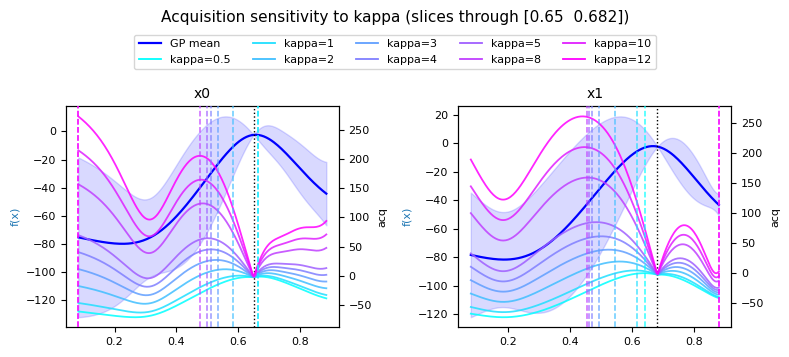

In [8]:
# Both the sweep and the bounds cross-check fit happen here, before any
# printing, so nothing interrupts the two tables below.
with fitting("kappa sweep + bounds cross-check"):
    kappa_rows = compare_kappa_proposals(
        X, y_logmag, bounds,
        kappa_values=[0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 10.0, 12.0],
        maximize=True, n_restarts=60, random_state=0)
    x_corner, _ = generate_next_point(X, y_logmag, bounds_standard, acquisition="ucb",
                                      kappa=3.0, maximize=True, n_restarts=40,
                                      random_state=0)
in_data = bool(np.all(X.min(axis=0) <= x_corner) and np.all(x_corner <= X.max(axis=0)))

print_kappa_comparison(kappa_rows)

# The function-1-specific read: UCB on log10|y| maximises MAGNITUDE and is blind
# to sign, so track how close each proposal drifts to the negative peak.
print(f"\n{'kappa':>6} {'x_next':>20} {'d(neg peak)':>12} {'d(incumbent)':>13}"
      f" {'nearest obs':>20} {'sign':>5} {'on box edge':>12}")
for r in kappa_rows:
    xn = np.asarray(r["x_next"])
    dists = np.linalg.norm(X - xn, axis=1)
    j = int(np.argmin(dists))
    edge = [f"x{k}" for k in range(D)
            if np.isclose(xn[k], bounds[k, 0], atol=1e-6)
            or np.isclose(xn[k], bounds[k, 1], atol=1e-6)]
    print(f"{r['kappa']:>6.1f} {str(np.round(xn, 4)):>20}"
          f" {np.linalg.norm(xn - neg_peak):>12.4f} {np.linalg.norm(xn - p_pos):>13.4f}"
          f" {str(np.round(X[j], 4)):>20} {'+' if y[j] > 0 else '-':>5}"
          f" {','.join(edge) or 'none':>12}")

# The bounds cross-check computed above: this is the evidence that the box-bounds
# deviation is load-bearing rather than a preference. Under the project-standard
# pad_fraction=1.0 bounds, the same GP and kappa run off to the far corner.
print(f"\nsame GP/kappa under bounds_standard would propose {np.round(x_corner, 4)}"
      f" -- inside the observed data: {in_data}")
print(f"  (bounds_standard upper corner is {np.round(bounds_standard[:, 1], 4)})")

fig = plot_kappa_sensitivity(X, y_logmag, bounds, gp_check, kappa_rows,
                             ucb_acquisition, maximize=True)
plt.show()

# Committed choice -- reused by the proposal, the contour plot, and the
# diagnostics replay below, so it's harder to make a mistake
KAPPA = 3.0



## Sign structure: what the surrogate cannot see

Diagnostic only — nothing here chooses the proposal, which is UCB's argmax. But `log10|y|` throws the sign away, so the sign structure has to be looked at separately or it is simply invisible.

Two facts worth re-reading each week:

- **The magnitude peak is the wrong sign.** `|y|`'s largest value is `−3.6e-3`, 13 orders of magnitude above anything else, so the region the surrogate finds most interesting is one we want to avoid.
- **Opposite-sign pairs bracket zero contours.** Between any positive and any negative observation, `y` must pass through zero. The closest such pair is only 0.0959 apart — the incumbent and the magnitude peak are neighbours — so `max y` lies somewhere just on the positive side of that contour.

The cell also checks whether the incumbent is a genuine local maximum or merely a point that happens to sit near a zero crossing, using its leave-one-out z-score on `log10|y|`. A z near 0 means the smooth magnitude trend already explains its value.

One caveat if you ever read predicted magnitudes *between* an opposite-sign pair: `|y| → 0` at the contour, so `log10|y| → −∞`, and a smooth GP with no data in the gap cannot represent that dip. It will over-predict magnitude there.

In [9]:
# Refit without the incumbent FIRST (section 3 needs it), so this fit cannot
# interleave with sections 1-2 printed below.
mask = np.ones(len(y), bool)
mask[i_pos_max] = False
with fitting("refit leaving the incumbent out"):
    gp_wo = fit_gp(X[mask], y_logmag[mask], bounds, n_restarts_optimizer=25,
                   random_state=0)
mu_wo, sd_wo = gp_wo.predict(normalize(p_pos.reshape(1, -1), bounds), return_std=True)
z_inc = float((y_logmag[i_pos_max] - mu_wo[0]) / sd_wo[0])
verdict = ("on the smooth magnitude trend; fast decay explains it" if abs(z_inc) < 1.0
           else "anomalous -- may sit near a zero contour")

print("=== 1. the magnitude peak is NEGATIVE ===")
print(f"  largest |y| : {np.round(neg_peak, 6)}  y = {y[i_abs_max]:+.4e}   <- what")
print("                log10|y| makes the GP chase, and the wrong sign")
print(f"  incumbent   : {np.round(p_pos, 6)}  y = {y[i_pos_max]:+.4e}   <- what we")
print("                are actually trying to beat")
print(f"  separation  : {np.linalg.norm(p_pos - neg_peak):.4f}"
      f"  ({np.log10(abs(y[i_abs_max] / y[i_pos_max])):.0f} orders of magnitude apart)")

print("\n=== 2. opposite-sign pairs: each brackets a zero contour ===")
pos_idx = np.flatnonzero(y > 0)
neg_idx = np.flatnonzero(y < 0)
pairs = sorted(((float(np.linalg.norm(X[i] - X[j])), i, j)
                for i in pos_idx for j in neg_idx))
for dist, i, j in pairs[:4]:
    print(f"  dist={dist:.4f}  +{np.round(X[i], 4)} (y={y[i]:+.2e})"
          f"  <->  -{np.round(X[j], 4)} (y={y[j]:+.2e})")
print("  -> max y lies just on the positive side of one of these contours;")
print("     nothing in the surrogate knows where they are.")

print("\n=== 3. is the incumbent a real local max, or just near a zero crossing? ===")
print(f"  actual log10|y| = {y_logmag[i_pos_max]:.2f},"
      f" predicted from the other {mask.sum()} = {mu_wo[0]:.2f} +/- {sd_wo[0]:.2f}")
print(f"  z = {z_inc:+.2f}  ->  {verdict}")

print("\n=== 4. sign counts, for the record ===")
print(f"  {len(pos_idx)} positive, {len(neg_idx)} negative."
      " A GP on sign(y) scores LOO R2 = -0.82 on this (see the evidence table),")
print("  so sign is measured, never predicted.")


[fitting: refit leaving the incumbent out] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
=== 1. the magnitude peak is NEGATIVE ===
  largest |y| : [0.650114 0.681526]  y = -3.6061e-03   <- what
                log10|y| makes the GP chase, and the wrong sign
  incumbent   : [0.731024 0.733   ]  y = +7.7109e-16   <- what we
                are actually trying to beat
  separation  : 0.0959  (13 orders of magnitude apart)

=== 2. opposite-sign pairs: each brackets a zero contour ===
  dist=0.0959  +[0.731 0.733] (y=+7.71e-16)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  dist=0.1029  +[0.8404 0.2647] (y=+3.34e-124)  <->  -[0.7606 0.1997] (y=-3.77e-115)
  dist=0.1826  +[0.6834 0.8611] (y=+2.54e-40)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  dist=0.2124  +[0.5743 0.8799] (y=+1.03e-46)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  -> max y lies just on the positive side of one of these contours;
     nothing in the surrogate knows where they are.

=== 3

## Propose the next point

Plain UCB argmax on the `log10|y|` surrogate, at the committed `KAPPA`. Two checks follow it:

- **Convex-hull membership**, which is the strong extrapolation test. Box bounds only guarantee that no coordinate exceeds the range seen on its own axis; a corner of the box can still sit well outside the data cloud.
- **The sign of the nearest observations**, since the surrogate is sign-blind. This does not change the proposal — it tells you what to expect from the result.

In [10]:
with fitting("UCB proposal"):
    x_next, gp = generate_next_point(
        X, y_logmag, bounds,
        acquisition="ucb",
        kappa=KAPPA,        # see the comparison above
        maximize=True,
        n_restarts=25,
        random_state=0,
    )

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)

mu_log, sigma_log = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"\npredicted log10|y| = {mu_log[0]:+.3f} +/- {sigma_log[0]:.3f}"
      f"   -> |y| ~ 1e{mu_log[0]:.0f}")
print(f"largest |y| on record: {np.abs(y).max():.4e} (log10 = {y_logmag.max():.2f});"
      f" incumbent y = {y.max():.4e}")

print("\n--- extrapolation checks ---")
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
on_edge = [f"x{d}" for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0], atol=1e-6)
           or np.isclose(x_next[d], bounds[d, 1], atol=1e-6)]
print("on a box edge:", ",".join(on_edge) or "none")
print("inside the convex hull (the strong test):", bool(hull.find_simplex(x_next) >= 0))
print(f"distance from the incumbent: {np.linalg.norm(x_next - p_pos):.4f}")

print("\n--- sign-blindness check: what is nearby, and what sign is it? ---")
print(f"distance to the NEGATIVE magnitude peak: {np.linalg.norm(x_next - neg_peak):.4f}")
print("nearest 4 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:4]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  sign={'+' if y[i] > 0 else '-'}"
          f"  y={y[i]:+.4e}  x={np.round(X[i], 4)}")
n_neg_near = sum(1 for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:4] if y[i] < 0)
print(f"-> {n_neg_near} of the 4 nearest observations"
      f" {'is' if n_neg_near == 1 else 'are'} negative"
      + (", and it is the closest one" if n_neg_near and
         y[int(np.argmin(np.linalg.norm(X - x_next, axis=1)))] < 0 else "") + ".")
print("   UCB is maximising |y| and cannot see sign, so a negative result is a real")
print("   possibility here -- that is the cost of a magnitude-only surrogate.")

# Hard gates: never submit a point outside the data cloud or with a negative
# coordinate (X is known never to be negative).
assert bool(hull.find_simplex(x_next) >= 0), "x_next is outside the convex hull"
assert np.all(x_next >= 0.0), "X is never negative -- proposal has a negative coordinate"


[fitting: UCB proposal] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
--- Next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.53388  0.493601]
0.96**2 * Matern(length_scale=[0.239, 0.274], nu=2.5) + WhiteKernel(noise_level=1e-06)

predicted log10|y| = -34.427 +/- 26.553   -> |y| ~ 1e-34
largest |y| on record: 3.6061e-03 (log10 = -2.44); incumbent y = 7.7109e-16

--- extrapolation checks ---
outside the observed range on its own axis: none
on a box edge: none
inside the convex hull (the strong test): True
distance from the incumbent: 0.3101

--- sign-blindness check: what is nearby, and what sign is it? ---
distance to the NEGATIVE magnitude peak: 0.2210
nearest 4 observations to x_next:
  dist=0.2210  sign=-  y=-3.6061e-03  x=[0.6501 0.6815]
  dist=0.3101  sign=+  y=+7.7109e-16  x=[0.731 0.733]
  dist=0.3443  sign=+  y=+1.3227e-79  x=[0.3194 0.763 ]
  dist=0.3528  sign=+  y=+2.3947e-54  x=[0.8854 0.5239]
-> 1 of the 4 nea

## Visualise the GP and acquisition function

Panels are in **`log10|y|` units**, not `y`. `y_scale` is deliberately not passed: it is a linear-rescale correction for a GP fit on `to_scaled_units(y, y_scale)`, and applying it to a log-magnitude surface would be a units error.

Two things to look for. The GP mean panel should show a single tight peak near (0.65, 0.68) — the magnitude peak, which is the *negative* observation. And the observation markers should make the sign structure visible: the peak and the incumbent are neighbours with opposite signs, so a zero contour runs between them — the dashed line marks that pair. `x_next` is UCB's argmax and is not placed relative to it.

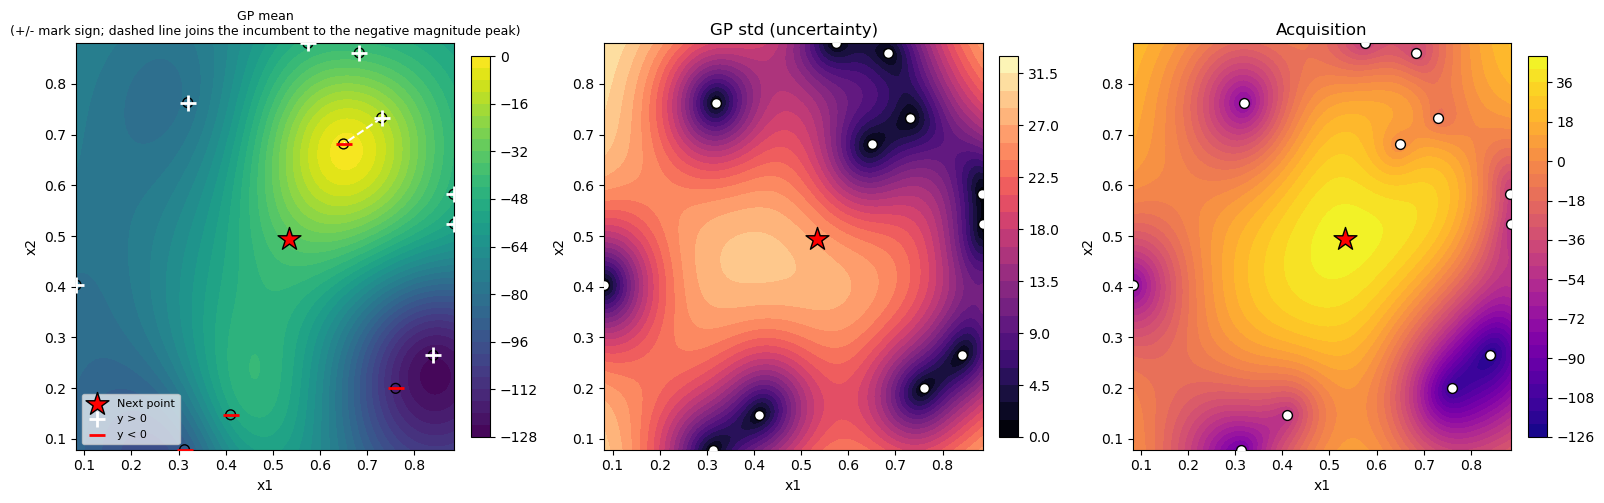

In [11]:
fig = plot_2d_bo(
    X, y_logmag, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
    y_scale=None,   # panels are log10|y|; a linear y_scale does not apply here
)

# Mark the sign structure, which the colour scale alone cannot show.
ax = fig.axes[0]
ax.scatter(X[y > 0, 0], X[y > 0, 1], marker="+", s=140, c="white", linewidths=2.0,
           label="y > 0", zorder=6)
ax.scatter(X[y < 0, 0], X[y < 0, 1], marker="_", s=140, c="red", linewidths=2.0,
           label="y < 0", zorder=6)
ax.plot([p_pos[0], neg_peak[0]], [p_pos[1], neg_peak[1]], "w--", lw=1.5, zorder=5)
ax.legend(loc="lower left", fontsize=8, framealpha=0.7)
ax.set_title(ax.get_title() + "\n(+/- mark sign; dashed line joins the incumbent"
             " to the negative magnitude peak)", fontsize=9)
plt.show()


## Sanity-check the surrogate: leave-one-out calibration

The numeric version of this is in the evidence table above; this is the visual one. Points should scatter about the diagonal with error bars that actually cover it.

[fitting: leave-one-out for the calibration plot] 12 warnings held back:
    12 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


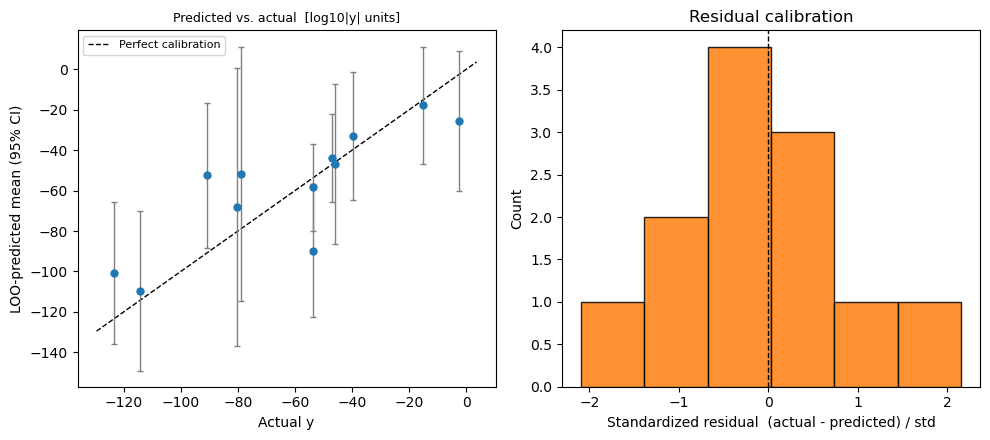

mean|z| = 0.80 (1.0 is ideal) | max|z| = 2.15
within 1 sigma: 8/12 | within 2 sigma: 10/12
worst-predicted point: x=[0.4104 0.1476] sign=- actual log10|y|=-53.7 predicted=-89.8 (z=+2.15)


In [12]:
with fitting("leave-one-out for the calibration plot"):
    pred_mean_log, pred_std_log = loo_predictions(
        X, y_logmag, bounds, gp_kwargs={"n_restarts_optimizer": 20})

# y_scale is NOT passed: these are log10|y| units, not a linear rescale of y.
fig = plot_loo_calibration(y_logmag, pred_mean_log, pred_std_log)
for ax in np.atleast_1d(fig.axes).ravel()[:1]:
    ax.set_title(ax.get_title() + "  [log10|y| units]", fontsize=9)
plt.show()

z = (y_logmag - pred_mean_log) / pred_std_log
print(f"mean|z| = {np.abs(z).mean():.2f} (1.0 is ideal) | max|z| = {np.abs(z).max():.2f}")
print(f"within 1 sigma: {int((np.abs(z) <= 1).sum())}/{len(z)}"
      f" | within 2 sigma: {int((np.abs(z) <= 2).sum())}/{len(z)}")
worst = int(np.argmax(np.abs(z)))
print(f"worst-predicted point: x={np.round(X[worst], 4)} sign={'+' if y[worst] > 0 else '-'}"
      f" actual log10|y|={y_logmag[worst]:.1f} predicted={pred_mean_log[worst]:.1f}"
      f" (z={z[worst]:+.2f})")


In [13]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))



0.533880-0.493601

full precision (use for next week's new_X):
0.5338798957921577-0.4936005300636206
